In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
import seaborn as sns

In [56]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [67]:
# Loading finches predictions for a window size of 31
calvados_pred_31 = pd.read_csv("../../Data/predict-tiles-31.csv", index_col=0)
tile_data = pd.read_csv("../../Data/tile_data_w_Ks.csv")

calvados_pred_31 = calvados_pred_31.drop(columns=['ArrayDNA', 'Activity_ratioA', 'Activity_ratioB', 'Activity_gfpA','Activity_gfpB', 'Activity_cherryA', 'Activity_cherryB','activity','result'])
calvados_pred_31 = calvados_pred_31.rename({"Seq" : "aa_seq"}, axis=1)
calvados_pred_31 = calvados_pred_31.merge(tile_data, on='aa_seq')

In [68]:
# We ended up using this window size, both look similar
calvados_pred_15 = pd.read_csv("../../Data/finches-structured_tile-data_calvados.csv", index_col = 0)
calvados_pred_15 = calvados_pred_15.rename(columns={'k' : 'K1'})

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


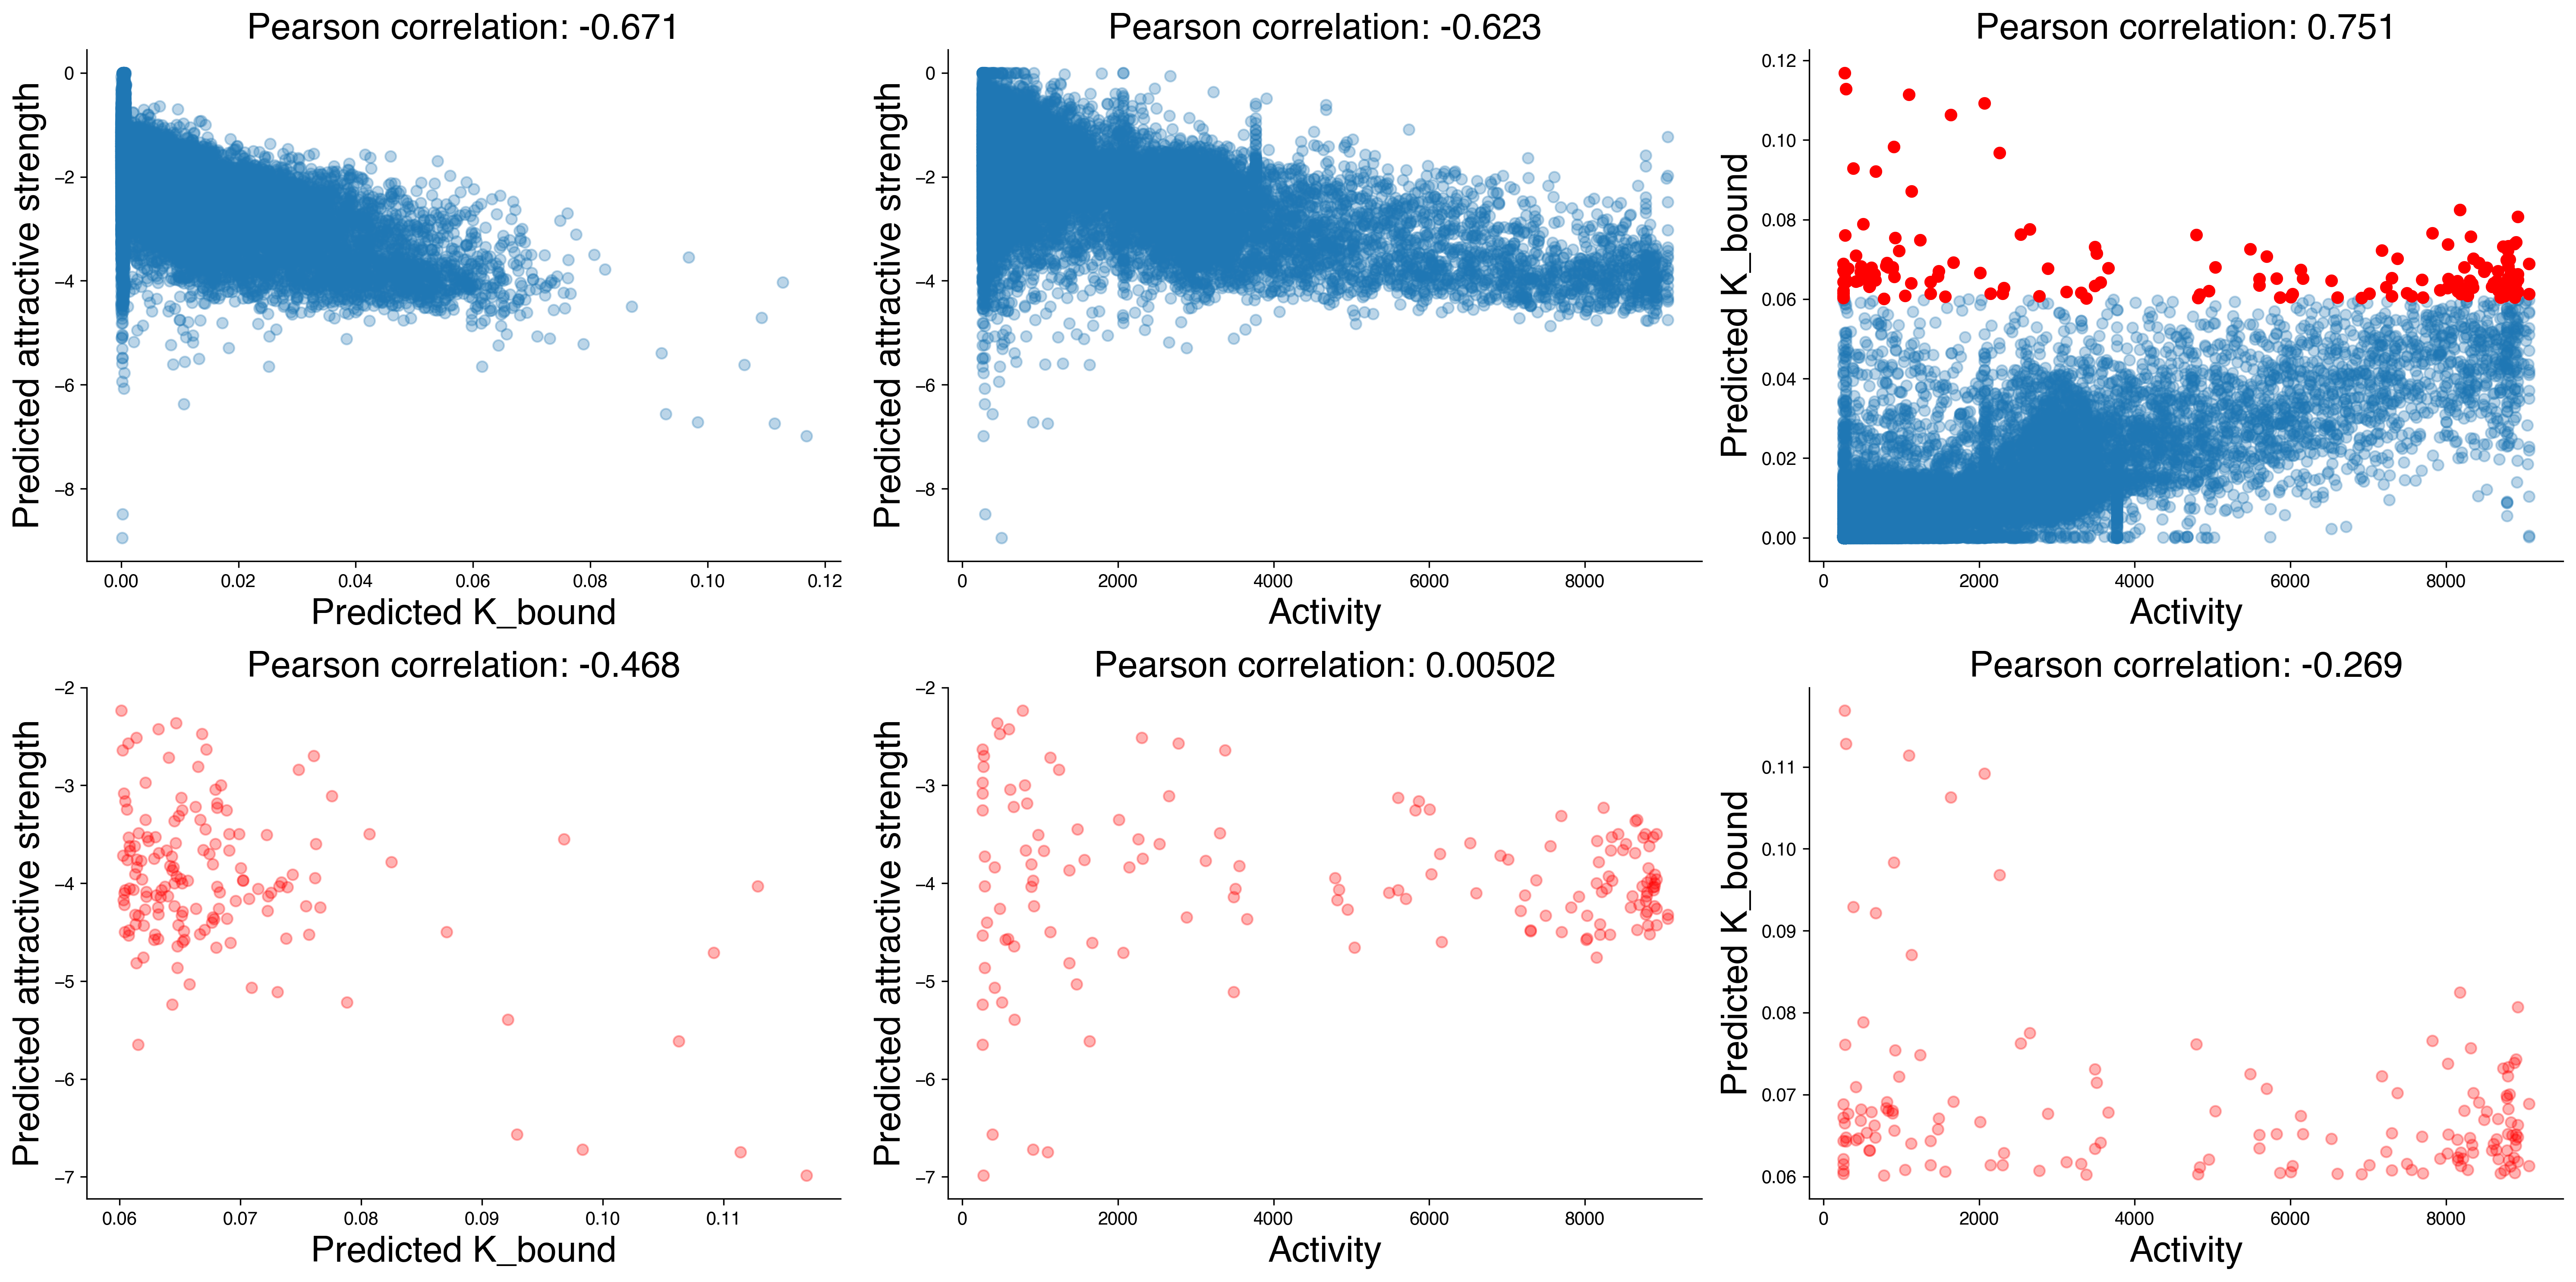

In [ ]:
# Make plot for window size of 31

fig, axs = plt.subplots(2,3, figsize=(20,10))

# Plot correlation between K1 and attractive epsilon
axs[0,0].scatter(calvados_pred_31["K1"], calvados_pred_31['attractive'], alpha=0.3)
p = pearsonr(calvados_pred_31["K1"], calvados_pred_31['attractive']).correlation
axs[0,0].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[0,0].set_xlabel("Predicted K_bound", fontsize=20)
axs[0,0].set_ylabel("Predicted attractive strength", fontsize=20)

# Plot correlation between activity and attractive epsilon
axs[0,1].scatter(calvados_pred_31["activity"], calvados_pred_31['attractive'], alpha=0.3)
p = pearsonr(calvados_pred_31["activity"], calvados_pred_31['attractive']).correlation
axs[0,1].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[0,1].set_xlabel("Activity", fontsize=20)
axs[0,1].set_ylabel("Predicted attractive strength", fontsize=20)

# Plot correlation between activity and K1
axs[0,2].scatter(calvados_pred_31["activity"], calvados_pred_31['K1'], alpha=0.3)
p = pearsonr(calvados_pred_31["activity"], calvados_pred_31['K1']).correlation
axs[0,2].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[0,2].set_ylabel("Predicted K_bound", fontsize=20)
axs[0,2].set_xlabel("Activity", fontsize=20)

# Pull out a subset with a high K1
subset = calvados_pred_31[calvados_pred_31["K1"] > 0.06]
axs[0,2].scatter(subset["activity"], subset['K1'], color="red") # Highlight these points in red

# Plot correlation between K1 and attractive epsilon in subset
axs[1,0].scatter(subset["K1"], subset['attractive'], color="red", alpha=0.3)
p = pearsonr(subset["K1"], subset['attractive']).correlation
axs[1,0].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[1,0].set_xlabel("Predicted K_bound", fontsize=20)
axs[1,0].set_ylabel("Predicted attractive strength", fontsize=20)

# Plot correlation between activity and attractive in subset
axs[1,1].scatter(subset["activity"], subset['attractive'], color="red", alpha=0.3)
p = pearsonr(subset["activity"], subset['attractive']).correlation
axs[1,1].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[1,1].set_xlabel("Activity", fontsize=20)
axs[1,1].set_ylabel("Predicted attractive strength", fontsize=20)

# Plot correlation between activity and K1 in subset
axs[1,2].scatter(subset["activity"], subset['K1'], color="red", alpha=0.3)
p = pearsonr(subset["activity"], subset['K1']).correlation
axs[1,2].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[1,2].set_xlabel("Activity", fontsize=20)
axs[1,2].set_ylabel("Predicted K_bound", fontsize=20)

sns.despine()
fig.tight_layout()

# plt.savefig("../../figures/finches_predictions.pdf", format='pdf', bbox_inches='tight')
# plt.savefig("../../figures/finches_predictions.png", format='png', bbox_inches='tight')


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


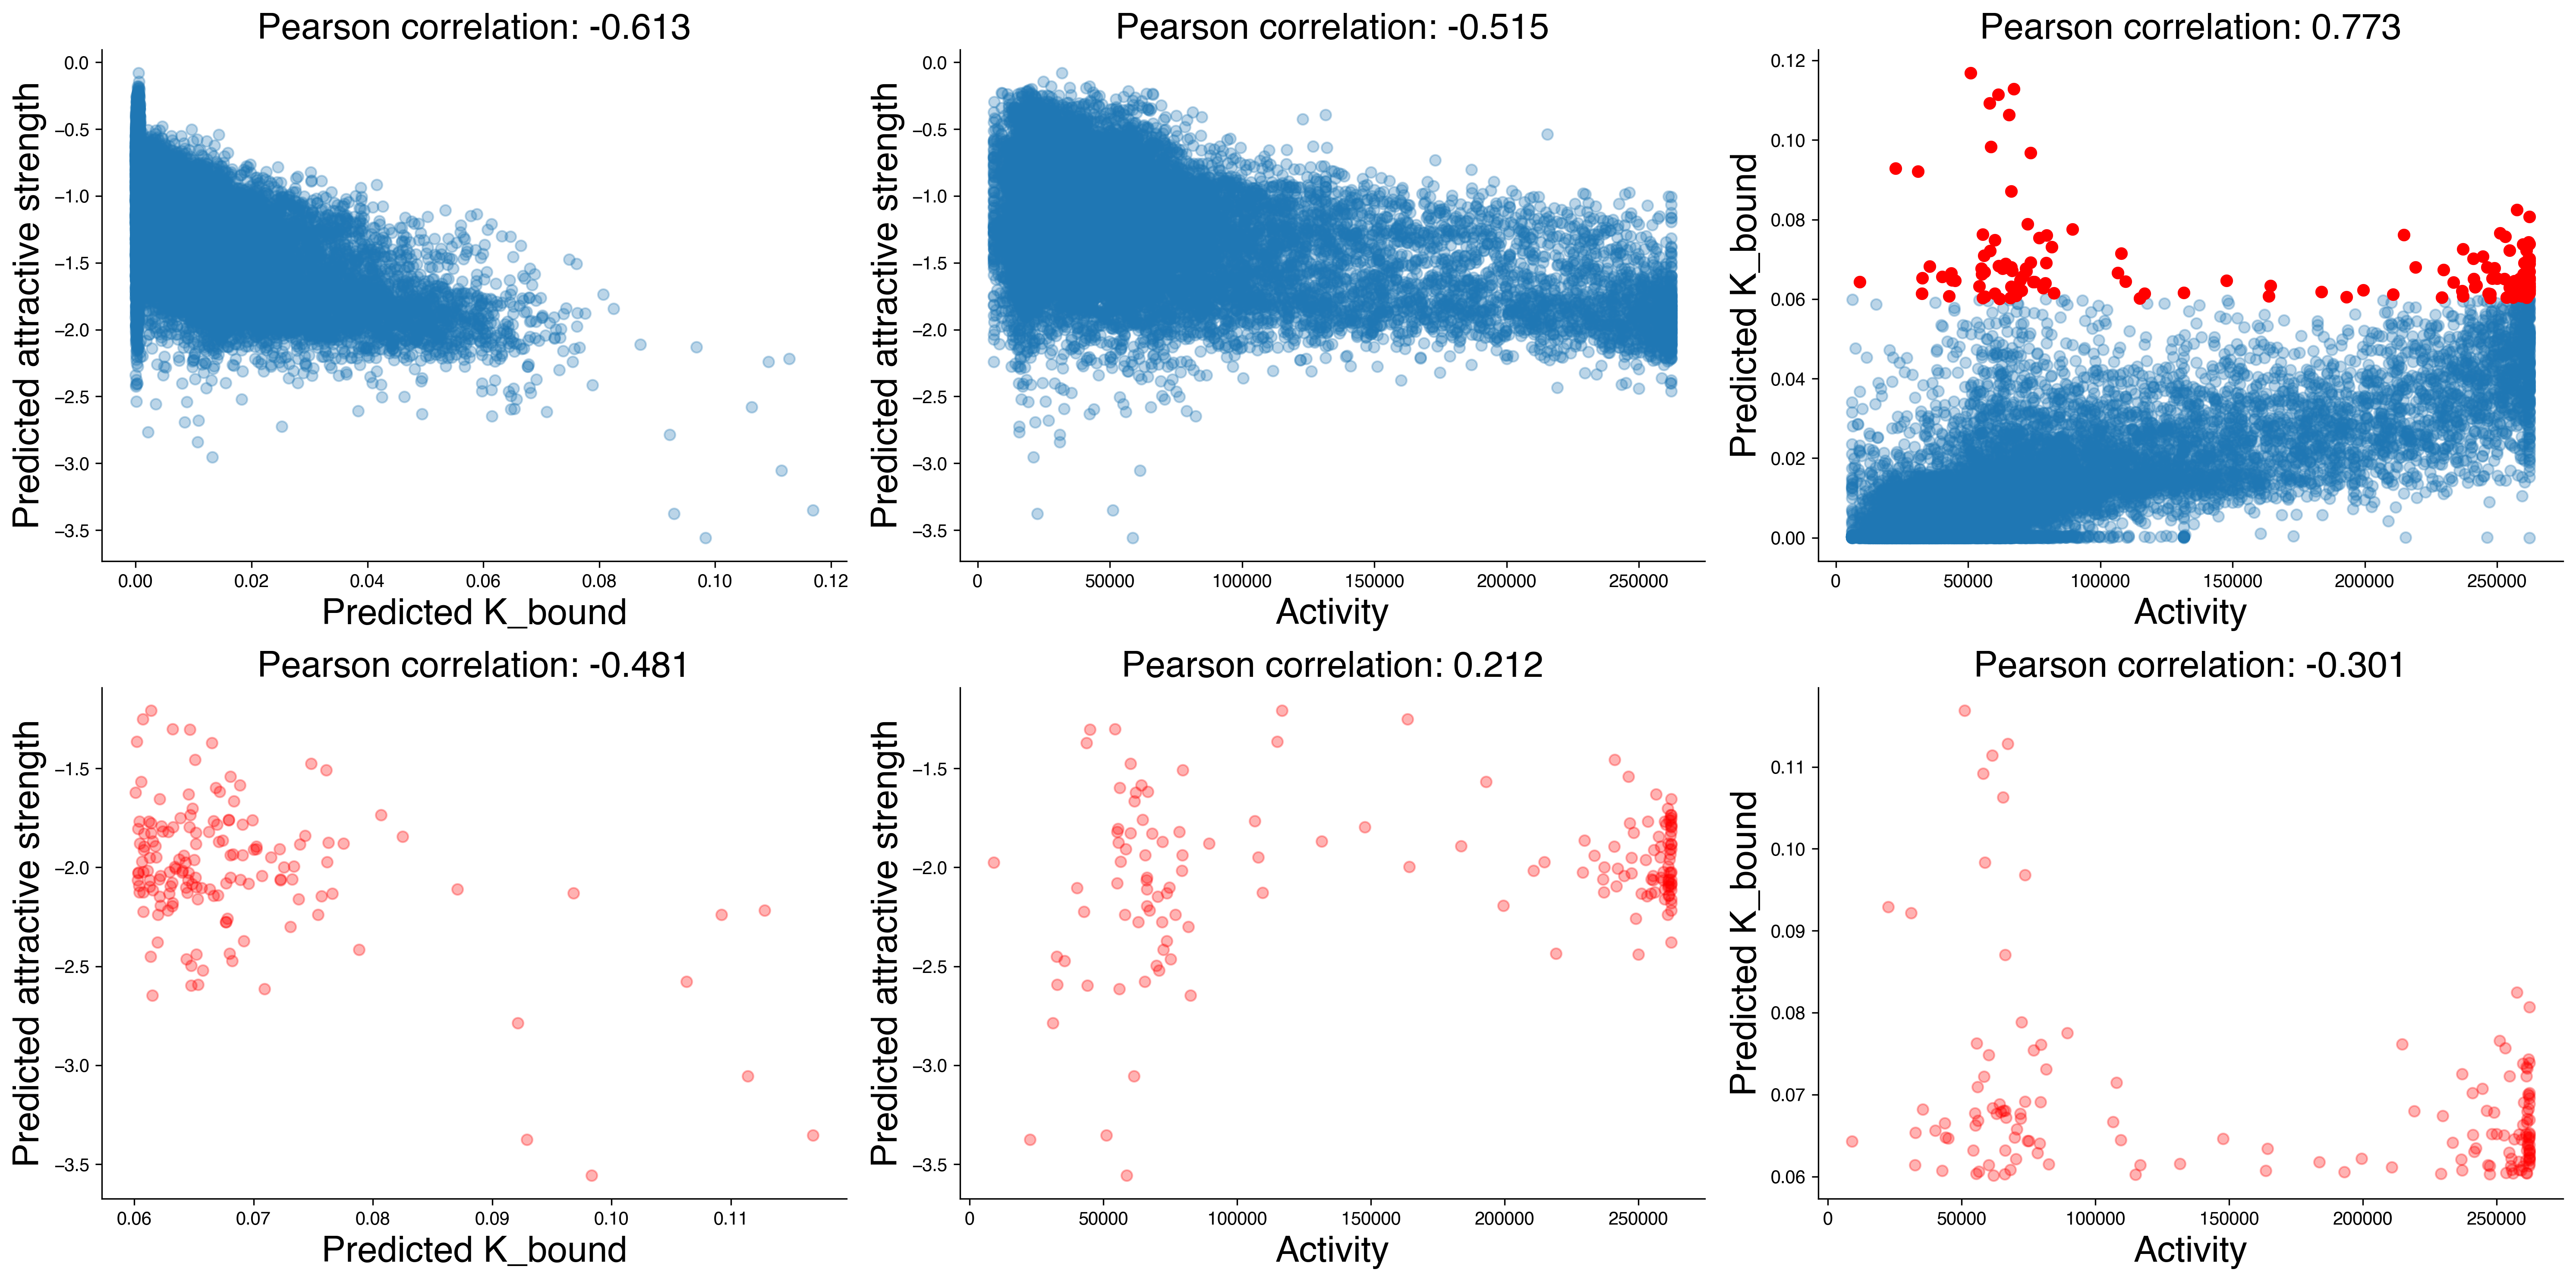

In [ ]:
# Make plot for window size of 15
fig, axs = plt.subplots(2,3, figsize=(20,10))

# Plot correlation between K1 and attractive epsilon
axs[0,0].scatter(calvados_pred_15["K1"], calvados_pred_15['attractive'], alpha=0.3)
p = pearsonr(calvados_pred_15["K1"], calvados_pred_15['attractive']).correlation
axs[0,0].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[0,0].set_xlabel("Predicted K_bound", fontsize=20)
axs[0,0].set_ylabel("Predicted attractive strength", fontsize=20)

# Plot correlation between activity and attractive epsilon
axs[0,1].scatter(calvados_pred_15["activity"], calvados_pred_15['attractive'], alpha=0.3)
p = pearsonr(calvados_pred_15["activity"], calvados_pred_15['attractive']).correlation
axs[0,1].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[0,1].set_xlabel("Activity", fontsize=20)
axs[0,1].set_ylabel("Predicted attractive strength", fontsize=20)

# Plot correlation between activity and K1
axs[0,2].scatter(calvados_pred_15["activity"], calvados_pred_15['K1'], alpha=0.3)
p = pearsonr(calvados_pred_15["activity"], calvados_pred_15['K1']).correlation
axs[0,2].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[0,2].set_ylabel("Predicted K_bound", fontsize=20)
axs[0,2].set_xlabel("Activity", fontsize=20)

# Pull out a subset with a high K1
subset = calvados_pred_15[calvados_pred_15["K1"] > 0.06]
axs[0,2].scatter(subset["activity"], subset['K1'], color="red") # Highlight the subset in red

# Plot correlation between K1 and attractive epsilon in subset
axs[1,0].scatter(subset["K1"], subset['attractive'], color="red", alpha=0.3)
p = pearsonr(subset["K1"], subset['attractive']).correlation
axs[1,0].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[1,0].set_xlabel("Predicted K_bound", fontsize=20)
axs[1,0].set_ylabel("Predicted attractive strength", fontsize=20)

# Plot correlation between activity and attractive epsilon in subset
axs[1,1].scatter(subset["activity"], subset['attractive'], color="red", alpha=0.3)
p = pearsonr(subset["activity"], subset['attractive']).correlation
axs[1,1].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[1,1].set_xlabel("Activity", fontsize=20)
axs[1,1].set_ylabel("Predicted attractive strength", fontsize=20)

# Plot correlation between activity and K1 in subset
axs[1,2].scatter(subset["activity"], subset['K1'], color="red", alpha=0.3)
p = pearsonr(subset["activity"], subset['K1']).correlation
axs[1,2].set_title(f"Pearson correlation: {p:.3}", fontsize=20)
axs[1,2].set_xlabel("Activity", fontsize=20)
axs[1,2].set_ylabel("Predicted K_bound", fontsize=20)

sns.despine()
fig.tight_layout()

plt.savefig("../../figures/finches_predictions.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../../figures/finches_predictions.png", format='png', bbox_inches='tight')
